<a href="https://colab.research.google.com/github/wiktorstudia/PUM_projekt/blob/main/Model_podstawowy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model podstawowy – Regresja Liniowa

**Cel:** Przewidywanie liczby wypożyczonych rowerów miejskich w każdej godzinie na podstawie danych pogodowych i czasowych.

**Model:** Regresja Liniowa (Linear Regression) – wybrany jako model bazowy (benchmark).

**Dane wejściowe:** `SeoulBikeData_processed_2.csv` – zbiór po preprocessingu (8760 instancji, 18 cech).

##Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    explained_variance_score,
    PredictionErrorDisplay
)

import warnings
warnings.filterwarnings('ignore')

print("Biblioteki zaimportowane poprawnie.")

Biblioteki zaimportowane poprawnie.


##Wczytanie danych

In [2]:
df = pd.read_csv('SeoulBikeData_processed_2.csv')

print(f"Kształt zbioru danych: {df.shape}")
print(f"Liczba instancji: {df.shape[0]}")
print(f"Liczba cech (łącznie z targetem): {df.shape[1]}")
print()
df.head()

Kształt zbioru danych: (8760, 18)
Liczba instancji: 8760
Liczba cech (łącznie z targetem): 18



,Rented Bike Count,Hour,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Day,Month,DayOfWeek,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
0,254,0.0,-5.2,37,2.2,2000,0.0,0.0,0.0,1,1,1,12,4,0,0,0,1
1,204,1.0,-5.5,38,0.8,2000,0.0,0.0,0.0,1,1,1,12,4,0,0,0,1
2,173,2.0,-6.0,39,1.0,2000,0.0,0.0,0.0,1,1,1,12,4,0,0,0,1
3,107,3.0,-6.2,40,0.9,2000,0.0,0.0,0.0,1,1,1,12,4,0,0,0,1
4,78,4.0,-6.0,36,2.3,2000,0.0,0.0,0.0,1,1,1,12,4,0,0,0,1


In [3]:
# Podstawowe informacje o zbiorze
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Rented Bike Count        8760 non-null   int64  
 1   Hour                     8760 non-null   float64
 2   Temperature(Â°C)         8760 non-null   float64
 3   Humidity(%)              8760 non-null   int64  
 4   Wind speed (m/s)         8760 non-null   float64
 5   Visibility (10m)         8760 non-null   int64  
 6   Solar Radiation (MJ/m2)  8760 non-null   float64
 7   Rainfall(mm)             8760 non-null   float64
 8   Snowfall (cm)            8760 non-null   float64
 9   Holiday                  8760 non-null   int64  
 10  Functioning Day          8760 non-null   int64  
 11  Day                      8760 non-null   int64  
 12  Month                    8760 non-null   int64  
 13  DayOfWeek                8760 non-null   int64  
 14  Season_Autumn           

In [4]:
# Statystyki opisowe
df.describe()

,Rented Bike Count,Hour,Temperature(Â°C),Humidity(%),Wind speed (m/s),Visibility (10m),Solar Radiation (MJ/m2),Rainfall(mm),Snowfall (cm),Holiday,Functioning Day,Day,Month,DayOfWeek,Season_Autumn,Season_Spring,Season_Summer,Season_Winter
count,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000,8760.000000
mean,704.602055,11.493379,12.882922,58.226256,1.724943,1436.825799,0.569111,0.148687,0.075068,0.950685,0.966324,15.720548,6.526027,3.002740,0.249315,0.252055,0.252055,0.246575
std,644.997468,6.926222,11.944825,20.362413,1.036067,608.298712,0.868746,1.128193,0.436746,0.216537,0.180404,8.796749,3.448048,1.998056,0.432641,0.434217,0.434217,0.431042
min,0.000000,0.000000,-17.800000,0.000000,0.000000,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,191.000000,5.000000,3.500000,42.000000,0.900000,940.000000,0.000000,0.000000,0.000000,1.000000,1.000000,8.000000,4.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,504.500000,11.000000,13.700000,57.000000,1.500000,1698.000000,0.010000,0.000000,0.000000,1.000000,1.000000,16.000000,7.000000,3.000000,0.000000,0.000000,0.000000,0.000000
75%,1065.250000,17.000000,22.500000,74.000000,2.300000,2000.000000,0.930000,0.000000,0.000000,1.000000,1.000000,23.000000,10.000000,5.000000,0.000000,1.000000,1.000000,0.000000
max,3556.000000,23.000000,39.400000,98.000000,7.400000,2000.000000,3.520000,35.000000,8.800000,1.000000,1.000000,31.000000,12.000000,6.000000,1.000000,1.000000,1.000000,1.000000


##Analiza zmiennej docelowej

Zmienna docelowa: **`Rented Bike Count`** – liczba rowerów wypożyczonych w danej godzinie.

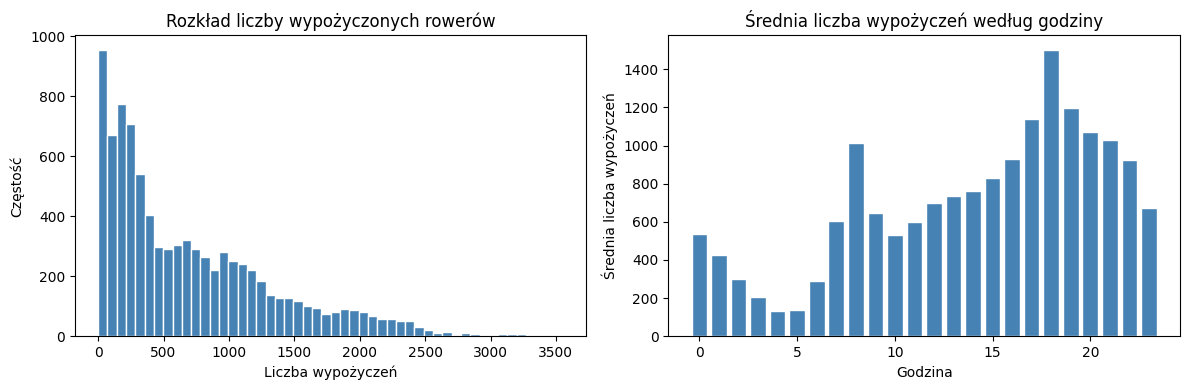

Średnia liczba wypożyczeń: 704.6
Mediana: 504.5
Min: 0, Max: 3556


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Rozkład zmiennej docelowej
axes[0].hist(df['Rented Bike Count'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Rozkład liczby wypożyczonych rowerów')
axes[0].set_xlabel('Liczba wypożyczeń')
axes[0].set_ylabel('Częstość')

# Wypożyczenia według godziny
avg_by_hour = df.groupby('Hour')['Rented Bike Count'].mean()
axes[1].bar(avg_by_hour.index, avg_by_hour.values, color='steelblue', edgecolor='white')
axes[1].set_title('Średnia liczba wypożyczeń według godziny')
axes[1].set_xlabel('Godzina')
axes[1].set_ylabel('Średnia liczba wypożyczeń')

plt.tight_layout()
plt.show()

print(f"Średnia liczba wypożyczeń: {df['Rented Bike Count'].mean():.1f}")
print(f"Mediana: {df['Rented Bike Count'].median():.1f}")
print(f"Min: {df['Rented Bike Count'].min()}, Max: {df['Rented Bike Count'].max()}")

##Podział na cechy (X) i zmienną docelową (y)

In [8]:
# Zmienna docelowa
y = df['Rented Bike Count']

# Cechy wejściowe (wszystkie kolumny oprócz targetu)
X = df.drop('Rented Bike Count', axis=1)

print(f"Kształt X: {X.shape}")
print(f"Kształt y: {y.shape}")
print(f"\nCechy wejściowe ({len(X.columns)}):\n{list(X.columns)}")

Kształt X: (8760, 17)
Kształt y: (8760,)

Cechy wejściowe (17):
['Hour', 'Temperature(Â°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)', 'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Holiday', 'Functioning Day', 'Day', 'Month', 'DayOfWeek', 'Season_Autumn', 'Season_Spring', 'Season_Summer', 'Season_Winter']


##Podział na zbiór treningowy i testowy (70% / 30%)

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

print(f"Zbiór treningowy: {X_train.shape[0]} instancji ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Zbiór testowy:    {X_test.shape[0]} instancji ({X_test.shape[0]/len(X)*100:.1f}%)")

Zbiór treningowy: 6132 instancji (70.0%)
Zbiór testowy:    2628 instancji (30.0%)


##Standaryzacja danych (StandardScaler)

In [10]:
scaler = StandardScaler()

# Dopasowanie i transformacja tylko na danych treningowych
X_train_scaled = scaler.fit_transform(X_train)

# Transformacja danych testowych (BEZ ponownego fit)
X_test_scaled = scaler.transform(X_test)

print("Standaryzacja zakończona.")
print(f"Średnia cech (train, po skalowaniu, próbka): {X_train_scaled.mean(axis=0)[:3].round(6)}")
print(f"Odch. std cech (train, po skalowaniu, próbka): {X_train_scaled.std(axis=0)[:3].round(6)}")

Standaryzacja zakończona.
Średnia cech (train, po skalowaniu, próbka): [-0.  0. -0.]
Odch. std cech (train, po skalowaniu, próbka): [1. 1. 1.]


##Budowa modelu – Regresja Liniowa (Benchmark)


In [11]:
# Trenowanie modelu
model = LinearRegression()
model.fit(X_train_scaled, y_train)

print("Model wytrenowany.")
print(f"\nWyraz wolny (intercept): {model.intercept_:.4f}")
print(f"\nWspółczynniki modelu:")
coef_df = pd.DataFrame({
    'Cecha': X.columns,
    'Współczynnik': model.coef_
}).sort_values('Współczynnik', ascending=False)
print(coef_df.to_string(index=False))

Model wytrenowany.

Wyraz wolny (intercept): 706.6350

Współczynniki modelu:
                  Cecha  Współczynnik
       Temperature(Â°C)    311.961831
                   Hour    196.607881
        Functioning Day    174.806125
          Season_Autumn     67.809829
                Holiday     27.507795
       Wind speed (m/s)     18.892124
                  Month     13.512000
          Season_Spring     11.799428
          Snowfall (cm)     10.053106
          Season_Summer      4.808805
       Visibility (10m)      1.471656
                    Day    -10.232490
              DayOfWeek    -20.140545
Solar Radiation (MJ/m2)    -71.382500
           Rainfall(mm)    -71.624037
          Season_Winter    -85.508966
            Humidity(%)   -165.268398


##Predykcja

In [13]:
# Predykcje na zbiorze treningowym i testowym
y_pred_train = model.predict(X_train_scaled)
y_pred_test  = model.predict(X_test_scaled)

# Obcinamy ujemne predykcje (liczba rowerów nie może być ujemna)
y_pred_train = np.maximum(y_pred_train, 0)
y_pred_test  = np.maximum(y_pred_test, 0)

print(f"Przykładowe predykcje (pierwsze 10 wartości ze zbioru testowego):")
comparison = pd.DataFrame({'Wartość rzeczywista': y_test.values[:10], 'Predykcja': y_pred_test[:10].round(1)})
print(comparison.to_string(index=False))

Przykładowe predykcje (pierwsze 10 wartości ze zbioru testowego):
 Wartość rzeczywista  Predykcja
                1728      944.4
                 822     1128.6
                 658     1390.1
                2716     1354.3
                1083      552.6
                 636      737.4
                1537     1530.2
                 712     1088.7
                 425      935.7
                 594      801.7


##Ocena modelu

### Miary oceny modelu regresji:

| Miara | Oznaczenie | Opis | Lepsza wartość |
|-------|------------|------|----------------|
| Błąd średniokwadratowy | MSE | Średnia kwadratów różnic między predykcją a wartością rzeczywistą. Penalizuje duże błędy mocniej. | Im niższe, tym lepiej |
| Pierwiastek błędu średniokwadratowego | RMSE | Pierwiastek MSE. W tej samej jednostce co target – łatwiejszy do interpretacji. | Im niższe, tym lepiej |
| Średni błąd absolutny | MAE | Średnia wartości bezwzględnych błędów. Mniej wrażliwy na wartości odstające niż MSE. | Im niższe, tym lepiej |
| Współczynnik determinacji | R² | Odsetek wariancji zmiennej docelowej wyjaśniany przez model. Wartość 1.0 = idealne dopasowanie. | Im wyższe (bliżej 1.0), tym lepiej |
| Wyjaśniona wariancja | EVS | Podobna do R², ale nie karze za systematyczne przesunięcie predykcji. | Im wyższe (bliżej 1.0), tym lepiej |

In [14]:
def evaluate_model(y_true, y_pred, label=''):
    """Oblicza i wyświetla metryki oceny modelu regresji."""
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    evs  = explained_variance_score(y_true, y_pred)

    print(f"{'─'*45}")
    print(f"  Wyniki – {label}")
    print(f"{'─'*45}")
    print(f"  MSE  (Mean Squared Error):      {mse:>10.2f}")
    print(f"  RMSE (Root MSE):                {rmse:>10.2f}")
    print(f"  MAE  (Mean Absolute Error):     {mae:>10.2f}")
    print(f"  R²   (Coefficient of Det.):     {r2:>10.4f}")
    print(f"  EVS  (Explained Variance):      {evs:>10.4f}")
    print(f"{'─'*45}")

    return {'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'R2': r2, 'EVS': evs}


print("\n=== OCENA MODELU REGRESJI LINIOWEJ ===\n")
metrics_train = evaluate_model(y_train, y_pred_train, label='Zbiór TRENINGOWY')
print()
metrics_test  = evaluate_model(y_test,  y_pred_test,  label='Zbiór TESTOWY')


=== OCENA MODELU REGRESJI LINIOWEJ ===

─────────────────────────────────────────────
  Wyniki – Zbiór TRENINGOWY
─────────────────────────────────────────────
  MSE  (Mean Squared Error):       177884.56
  RMSE (Root MSE):                    421.76
  MAE  (Mean Absolute Error):         305.91
  R²   (Coefficient of Det.):         0.5751
  EVS  (Explained Variance):          0.5757
─────────────────────────────────────────────

─────────────────────────────────────────────
  Wyniki – Zbiór TESTOWY
─────────────────────────────────────────────
  MSE  (Mean Squared Error):       178203.36
  RMSE (Root MSE):                    422.14
  MAE  (Mean Absolute Error):         307.62
  R²   (Coefficient of Det.):         0.5651
  EVS  (Explained Variance):          0.5656
─────────────────────────────────────────────


In [15]:
# Zestawienie wyników – tabela porównawcza (przydatna do późniejszego porównania z innymi modelami)
results = pd.DataFrame({
    'Metryka': ['MSE', 'RMSE', 'MAE', 'R²', 'EVS'],
    'Zbiór treningowy': [
        round(metrics_train['MSE'], 2),
        round(metrics_train['RMSE'], 2),
        round(metrics_train['MAE'], 2),
        round(metrics_train['R2'], 4),
        round(metrics_train['EVS'], 4)
    ],
    'Zbiór testowy': [
        round(metrics_test['MSE'], 2),
        round(metrics_test['RMSE'], 2),
        round(metrics_test['MAE'], 2),
        round(metrics_test['R2'], 4),
        round(metrics_test['EVS'], 4)
    ]
})

print("\n=== TABELA WYNIKÓW – BENCHMARK (Regresja Liniowa) ===")
print(results.to_string(index=False))


=== TABELA WYNIKÓW – BENCHMARK (Regresja Liniowa) ===
Metryka  Zbiór treningowy  Zbiór testowy
    MSE       177884.5600    178203.3600
   RMSE          421.7600       422.1400
    MAE          305.9100       307.6200
     R²            0.5751         0.5651
    EVS            0.5757         0.5656


##Wizualizacja wyników

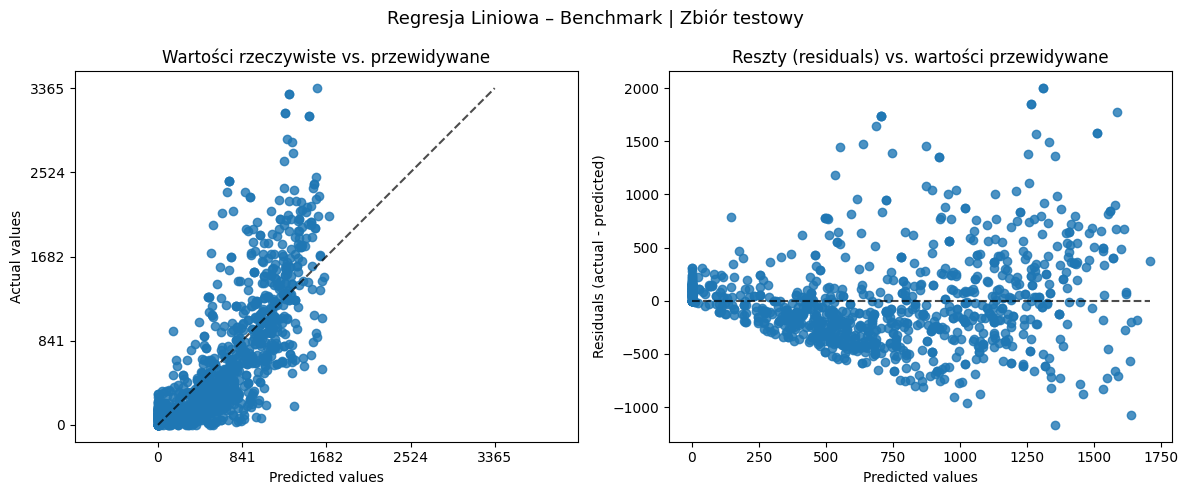

In [16]:
# Wykres: Wartości rzeczywiste vs. przewidywane
fig, axs = plt.subplots(ncols=2, figsize=(12, 5))

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred_test,
    kind="actual_vs_predicted",
    ax=axs[0],
    random_state=42
)
axs[0].set_title('Wartości rzeczywiste vs. przewidywane')

PredictionErrorDisplay.from_predictions(
    y_test,
    y_pred=y_pred_test,
    kind="residual_vs_predicted",
    ax=axs[1],
    random_state=42
)
axs[1].set_title('Reszty (residuals) vs. wartości przewidywane')

fig.suptitle('Regresja Liniowa – Benchmark | Zbiór testowy', fontsize=13)
plt.tight_layout()
plt.show()

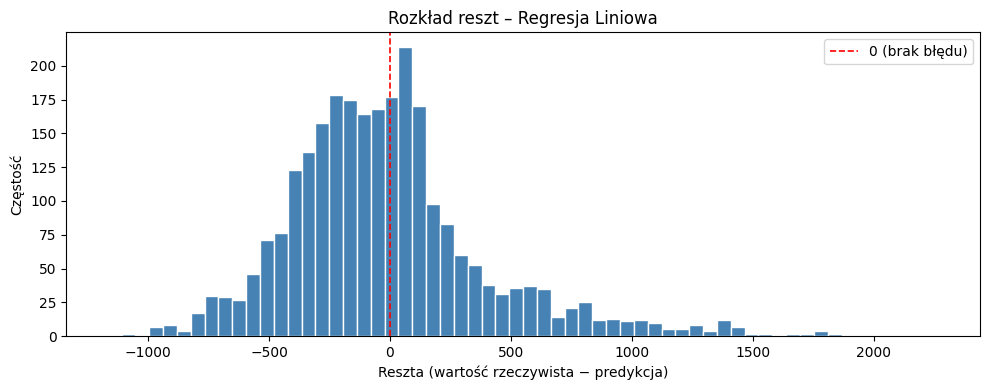

Średnia reszt: -13.79  (powinno być bliskie 0)
Odch. std reszt: 421.92


In [17]:
# Rozkład reszt (błędów)
residuals = y_test.values - y_pred_test

plt.figure(figsize=(10, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(x=0, color='red', linestyle='--', linewidth=1.2, label='0 (brak błędu)')
plt.title('Rozkład reszt – Regresja Liniowa')
plt.xlabel('Reszta (wartość rzeczywista − predykcja)')
plt.ylabel('Częstość')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Średnia reszt: {residuals.mean():.2f}  (powinno być bliskie 0)")
print(f"Odch. std reszt: {residuals.std():.2f}")